# 06. Классификатор превышения порога оталькования

Сегментационные модели пока нестабильно оценивают площадь областей
оталькования. Поэтому для итогового решения добавляется отдельный
классификатор:

- `talc_over_10` — изображение относится к оталькованной руде;
- `non_talc` — рядовая или труднообогатимая руда.

Все изображения из папки `talc` считаются примерами условия
«талька более 10%», согласно постановке задачи.

Сегментация остаётся в системе для визуального объяснения и оценки площади,
но итоговое прохождение порога 10% поддерживается отдельной моделью.

In [1]:
from pathlib import Path

INVENTORY_PATH = Path("outputs/audit/dataset_inventory.csv")
OUTPUT_DIR = Path("outputs/talc_gate")
MODEL_DIR = Path("models")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert INVENTORY_PATH.exists(), (
    f"Не найден {INVENTORY_PATH}. "
    "Сначала выполните 01_data_audit.ipynb."
)

IMAGE_SIZE = 224
BATCH_SIZE = 24
HEAD_EPOCHS = 4
FINETUNE_EPOCHS = 4
RANDOM_SEED = 42

print("Inventory:", INVENTORY_PATH.resolve())

Inventory: C:\Users\Мария\ore_hackathon\outputs\audit\dataset_inventory.csv


In [2]:
import hashlib
import json
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageOps
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
Image.MAX_IMAGE_PIXELS = None


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


## 1. Подготовка выборки

In [3]:
inventory = pd.read_csv(
    INVENTORY_PATH,
    encoding="utf-8-sig",
)

frame = inventory[
    inventory["label"].isin([
        "ordinary",
        "fine",
        "talc",
    ])
].copy()

frame["target"] = (
    frame["label"] == "talc"
).astype(int)

frame["target_name"] = frame["target"].map({
    0: "non_talc",
    1: "talc_over_10",
})

frame = frame[
    frame["absolute_path"].map(
        lambda path: Path(str(path)).exists()
    )
].copy()

# Удаляем pHash-конфликты: один визуально одинаковый кадр не должен иметь
# одновременно talc и non_talc.
conflicting_phashes = (
    frame.groupby("phash")["target"]
    .nunique()
)

conflicting_phashes = set(
    conflicting_phashes[
        conflicting_phashes > 1
    ].index
)

frame = frame[
    ~frame["phash"].isin(conflicting_phashes)
].copy()

# Дубли внутри одного класса: оставляем кадр максимального разрешения.
frame["pixel_count"] = (
    frame["width"].fillna(0)
    * frame["height"].fillna(0)
)

frame = (
    frame.sort_values(
        ["phash", "pixel_count", "file_size_mb"],
        ascending=[True, False, False],
    )
    .drop_duplicates("phash", keep="first")
    .copy()
)


def deterministic_split(group_name: str) -> str:
    value = int(
        hashlib.md5(
            str(group_name).encode("utf-8")
        ).hexdigest()[:8],
        16,
    ) / 0xFFFFFFFF

    if value < 0.15:
        return "validation"
    if value < 0.25:
        return "test"
    return "train"


frame["split"] = (
    frame["sample_group"]
    .fillna(frame["filename"])
    .map(deterministic_split)
)

frame.to_csv(
    OUTPUT_DIR / "talc_gate_manifest.csv",
    index=False,
    encoding="utf-8-sig",
)

display(
    frame.groupby(
        ["split", "target_name"]
    ).size().unstack(fill_value=0)
)

leakage = (
    frame.groupby("sample_group")["split"]
    .nunique()
    .gt(1)
    .sum()
)

assert leakage == 0
print("Конфликтных pHash удалено:", len(conflicting_phashes))

target_name,non_talc,talc_over_10
split,,
test,108,13
train,728,81
validation,159,21


Конфликтных pHash удалено: 11


## 2. Dataset и аугментации

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.72, 1.0),
        ratio=(0.85, 1.15),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.18,
        contrast=0.18,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class GateDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        with Image.open(row["absolute_path"]) as image:
            image = ImageOps.exif_transpose(
                image
            ).convert("RGB")

        return {
            "image": self.transform(image),
            "label": torch.tensor(
                int(row["target"]),
                dtype=torch.long,
            ),
            "path": row["absolute_path"],
        }


frames = {
    split: frame[
        frame["split"] == split
    ].copy()
    for split in [
        "train",
        "validation",
        "test",
    ]
}

datasets = {
    "train": GateDataset(
        frames["train"],
        train_transform,
    ),
    "validation": GateDataset(
        frames["validation"],
        eval_transform,
    ),
    "test": GateDataset(
        frames["test"],
        eval_transform,
    ),
}

train_targets = frames["train"]["target"].to_numpy()
class_counts = np.bincount(
    train_targets,
    minlength=2,
)

sample_weights = np.array([
    1.0 / class_counts[target]
    for target in train_targets
])

sampler = WeightedRandomSampler(
    weights=torch.tensor(
        sample_weights,
        dtype=torch.double,
    ),
    num_samples=len(sample_weights),
    replacement=True,
)

loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=0,
    ),
    "validation": DataLoader(
        datasets["validation"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    ),
}

print({
    split: len(dataset)
    for split, dataset in datasets.items()
})

{'train': 809, 'validation': 180, 'test': 121}


## 3. MobileNetV3-Small

In [5]:
model = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.DEFAULT,
)

for parameter in model.features.parameters():
    parameter.requires_grad = False

input_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(
    input_features,
    2,
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

## 4. Обучение и метрики

In [6]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)

    losses = []
    true_values = []
    predictions = []
    probabilities = []
    paths = []

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:
        for batch in tqdm(loader, leave=False):
            images = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            if training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                loss.backward()
                optimizer.step()

            probability = torch.softmax(
                logits,
                dim=1,
            )[:, 1]

            predicted = (
                probability >= 0.5
            ).long()

            losses.append(
                loss.item() * len(labels)
            )
            true_values.extend(
                labels.cpu().numpy()
            )
            predictions.extend(
                predicted.detach().cpu().numpy()
            )
            probabilities.extend(
                probability.detach().cpu().numpy()
            )
            paths.extend(batch["path"])

    metrics = { 
        "loss": sum(losses) / len(true_values),
        "accuracy": accuracy_score(
            true_values,
            predictions,
        ),
        "f1": f1_score(
            true_values,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            true_values,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            true_values,
            probabilities,
        ),
    }

    result = pd.DataFrame({
        "path": paths,
        "true": true_values,
        "predicted": predictions,
        "prob_talc_over_10": probabilities,
    })

    return metrics, result


def train_stage(
    stage_name,
    epochs,
    optimizer,
    best_auc,
    history,
):
    for epoch in range(1, epochs + 1):
        started = time.time()

        train_metrics, _ = run_epoch(
            model,
            loaders["train"],
            optimizer,
        )

        validation_metrics, validation_predictions = run_epoch(
            model,
            loaders["validation"],
        )

        history.append({
            "stage": stage_name,
            "epoch": epoch,
            "seconds": time.time() - started,
            **{
                f"train_{key}": value
                for key, value in train_metrics.items()
            },
            **{
                f"validation_{key}": value
                for key, value in validation_metrics.items()
            },
        })

        print(
            f"[{stage_name}] {epoch}/{epochs} | "
            f"val F1={validation_metrics['f1']:.4f} | "
            f"val AUC={validation_metrics['roc_auc']:.4f}"
        )

        if validation_metrics["roc_auc"] > best_auc:
            best_auc = validation_metrics["roc_auc"]

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "architecture": "mobilenet_v3_small",
                    "label_to_id": {
                        "non_talc": 0,
                        "talc_over_10": 1,
                    },
                    "image_size": IMAGE_SIZE,
                    "validation_roc_auc": best_auc,
                },
                MODEL_DIR / "talc_gate_mobilenet_v3_small.pth",
            )

            validation_predictions.to_csv(
                OUTPUT_DIR / "best_validation_predictions.csv",
                index=False,
                encoding="utf-8-sig",
            )

    return best_auc, history


history = []
best_auc = -1.0

optimizer = AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

best_auc, history = train_stage(
    "head",
    HEAD_EPOCHS,
    optimizer,
    best_auc,
    history,
)

for block in list(model.features.children())[-3:]:
    for parameter in block.parameters():
        parameter.requires_grad = True

optimizer = AdamW(
    (
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ),
    lr=2e-4,
    weight_decay=1e-4,
)

best_auc, history = train_stage(
    "finetune",
    FINETUNE_EPOCHS,
    optimizer,
    best_auc,
    history,
)

history_frame = pd.DataFrame(history)
history_frame.to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
    encoding="utf-8-sig",
)

display(history_frame)

  0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

[head] 1/4 | val F1=0.3810 | val AUC=0.8155


  0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

...

[finetune] 3/4 | val F1=0.5763 | val AUC=0.9203


  0%|          | 0/34 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

[finetune] 4/4 | val F1=0.6207 | val AUC=0.9230


,stage,epoch,seconds,train_loss,train_accuracy,train_f1,train_roc_auc,train_pr_auc,validation_loss,validation_accuracy,validation_f1,validation_roc_auc,validation_pr_auc
0,head,1,90.927998,0.383976,0.819530,0.816583,0.905954,0.909007,0.559363,0.711111,0.380952,0.815514,0.463008
1,head,2,94.783151,0.249973,0.896168,0.899522,0.962186,0.966300,0.248006,0.911111,0.600000,0.882300,0.605865
2,head,3,98.191533,0.274409,0.891224,0.886889,0.954986,0.939376,0.348404,0.877778,0.607143,0.899371,0.658471
3,head,4,97.059355,0.214184,0.914710,0.913642,0.972416,0.970974,0.579453,0.766667,0.461538,0.900270,0.581295
4,finetune,1,101.067851,0.183940,0.927070,0.930994,0.979380,0.980189,0.557962,0.788889,0.500000,0.900569,0.663147
5,finetune,2,100.617283,0.124236,0.959209,0.958175,0.991527,0.990234,0.385601,0.872222,0.596491,0.911650,0.740116
6,finetune,3,99.724564,0.103357,0.957973,0.958435,0.994211,0.994547,0.354969,0.861111,0.576271,0.920335,0.788848
7,finetune,4,97.188224,0.095048,0.967862,0.966321,0.993764,0.991844,0.367439,0.877778,0.620690,0.923031,0.790243


## 5. Test

  0%|          | 0/6 [00:00<?, ?it/s]

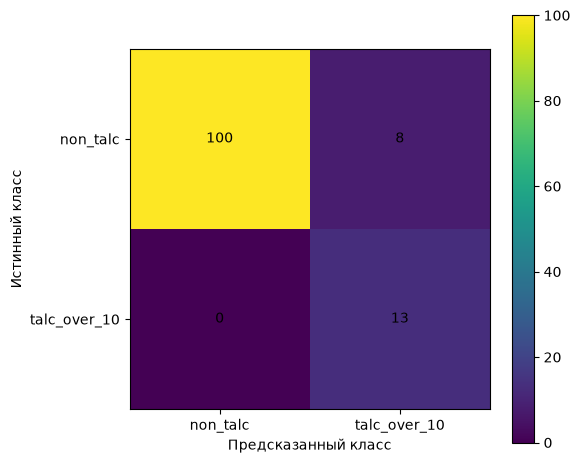

{
  "loss": 0.1381221394216226,
  "accuracy": 0.9338842975206612,
  "f1": 0.7647058823529411,
  "roc_auc": 1.0,
  "pr_auc": 1.0
}


In [7]:
checkpoint_path = (
    MODEL_DIR / "talc_gate_mobilenet_v3_small.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

test_metrics, test_predictions = run_epoch(
    model,
    loaders["test"],
)

test_predictions.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

report = classification_report(
    test_predictions["true"],
    test_predictions["predicted"],
    target_names=[
        "non_talc",
        "talc_over_10",
    ],
    output_dict=True,
    zero_division=0,
)

pd.DataFrame(report).T.to_csv(
    OUTPUT_DIR / "test_classification_report.csv",
    encoding="utf-8-sig",
)

matrix = confusion_matrix(
    test_predictions["true"],
    test_predictions["predicted"],
)

fig, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(matrix)

axis.set_xticks(
    [0, 1],
    ["non_talc", "talc_over_10"],
)
axis.set_yticks(
    [0, 1],
    ["non_talc", "talc_over_10"],
)
axis.set_xlabel("Предсказанный класс")
axis.set_ylabel("Истинный класс")

for row in range(2):
    for column in range(2):
        axis.text(
            column,
            row,
            str(matrix[row, column]),
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=axis)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print(json.dumps(
    test_metrics,
    indent=2,
))

In [8]:
print("=" * 72)
print("TALC GATE TRAINING FINISHED")
print("=" * 72)
print("Validation best AUC:", best_auc)
print("Test F1:", test_metrics["f1"])
print("Test ROC-AUC:", test_metrics["roc_auc"])
print("Test PR-AUC:", test_metrics["pr_auc"])
print("Model:", checkpoint_path.resolve())

TALC GATE TRAINING FINISHED
Validation best AUC: 0.9230308475591495
Test F1: 0.7647058823529411
Test ROC-AUC: 1.0
Test PR-AUC: 1.0
Model: C:\Users\Мария\ore_hackathon\models\talc_gate_mobilenet_v3_small.pth
